### Configuration, inputs & outputs

In [1]:
from pipeline_utils import make_case2_paths, load_expert_rating_labels
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from matplotlib.colors import ListedColormap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, precision_recall_fscore_support

RANDOM_STATE = 42
CATEGORIES = [f"cat{i}" for i in range(1, 6)]
MRECIST_MAP = {"CR": 0, "PR": 1, "SD": 2, "PD": 3}
FEATURES = [
    "model_mRECIST_encoded", "model_best.response", "model_best.response.time",
    "model_best.average.response", "model_best.average.response.time",
    "model_AUC", "model_slope", "batch_slope.control",
    "batch_slope.treatment", "batch_angle", "batch_auc.control",
    "batch_auc.treatment", "batch_abc", "batch_TGI",
]
PARAM_GRID = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

# Configure paths
paths = make_case2_paths()

PROJECT_DIR = paths["project"]
PROC_DIR = paths["proc"]
RAW_DIR = paths["raw_pdxe"]

print(f"Project directory: {PROJECT_DIR}")
print(f"Processed data directory: {PROC_DIR}")

# Input files
expert_rating_table = PROC_DIR / "expert_rating" / "expert_rating_summary.csv"
fold_table = PROC_DIR / "ml_cv_fold_assignment.csv"
manifest_table = RAW_DIR / "xeva_sensitivity" / "manifest.csv"

df_clean = load_expert_rating_labels(expert_rating_table)
fold_df = pd.read_csv(fold_table)
print(f"Loaded {len(fold_df)} labeled figures across {fold_df['fold'].nunique()} folds")

# Output files
checkpoint_dir = PROC_DIR / "ml_model" / "random_forest"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

fold_results_table = checkpoint_dir / "rf_cv_fold_results.csv"
predictions_table = checkpoint_dir / "rf_cv_predictions.csv"
summary_table = checkpoint_dir / "rf_cv_summary.csv"
confusion_table = checkpoint_dir / "rf_cv_confusion_matrix.csv"
confusion_fig = checkpoint_dir / "rf_cv_confusion_matrix.png"
importance_table = checkpoint_dir / "rf_final_feature_importance.csv"
importance_fig = checkpoint_dir / "rf_final_feature_importance.png"
shap_fig = checkpoint_dir / "rf_final_shap_summary.png"
shap_by_class_table = checkpoint_dir / "rf_final_shap_by_class.csv"

print(f"Checkpoint directory: {checkpoint_dir}")

### Feature engineering

Merge in the Xeva response statistics (mRECIST, slopes, AUCs, angle, TGI, ...) that were already computed per model-drug pair, encode `model_mRECIST` numerically, and share the same fold assignment used by the ResNet18 notebook.

In [2]:
stats_df = pd.read_csv(manifest_table).drop(columns=["batch_id", "model_id", "image_file"])
df = fold_df.merge(stats_df, on="figure_id", how="left")
df["model_mRECIST_encoded"] = df["model_mRECIST"].map(MRECIST_MAP)

print(f"Merged feature table: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"NaNs in feature columns: {int(df[FEATURES].isnull().sum().sum())}")

inf_counts = {c: int(np.isinf(df[c]).sum()) for c in FEATURES if np.isinf(df[c]).any()}
print(f"Columns with Inf values: {inf_counts}")

Merged feature table: 1267 rows, 19 columns
NaNs in feature columns: 0
Columns with Inf values: {'batch_TGI': 2}


### Per-fold training and evaluation

`GridSearchCV` already runs its own inner CV within each fold's training pool, so unlike ResNet18 there is no separate validation carve-out to build -- the inner grid search *is* the model-selection mechanism, re-derived independently for every outer fold. The `batch_TGI` Inf values are clipped using bounds computed from that fold's training pool only, then applied to both train and test, so no information from the held-out fold leaks into the clip bounds.

In [3]:
def clip_infinite_values(df, reference_df, columns):
    """Clip +/-inf to the finite max/min observed in `reference_df` (the training pool)."""
    df = df.copy()
    for col in columns:
        finite_vals = reference_df.loc[np.isfinite(reference_df[col]), col]
        df[col] = df[col].replace(np.inf, finite_vals.max())
        df[col] = df[col].replace(-np.inf, finite_vals.min())
    return df


def train_one_fold(fold_idx, df):
    test_df = df[df["fold"] == fold_idx].copy()
    train_df = df[df["fold"] != fold_idx].copy()

    inf_cols = [c for c in FEATURES if np.isinf(train_df[c]).any() or np.isinf(test_df[c]).any()]
    train_df = clip_infinite_values(train_df, train_df, inf_cols)
    test_df = clip_infinite_values(test_df, train_df, inf_cols)

    X_train, y_train = train_df[FEATURES], train_df["label"]
    X_test, y_test = test_df[FEATURES], test_df["label"]

    grid_search = GridSearchCV(
        RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        PARAM_GRID, cv=5, scoring="f1_macro", n_jobs=-1,
    )
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_

    y_pred = best_rf.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    fold_result = {
        "fold": fold_idx,
        "n_train": len(train_df),
        "n_test": len(test_df),
        "best_params": grid_search.best_params_,
        "test_macro_precision": precision,
        "test_macro_recall": recall,
        "test_macro_f1": f1,
        "test_balanced_accuracy": balanced_acc,
    }
    predictions_df = pd.DataFrame({
        "figure_id": test_df["figure_id"].values,
        "fold": fold_idx,
        "true_label": y_test.values,
        "pred_label": y_pred,
    })
    return fold_result, predictions_df

### Run 5-fold cross-validation

In [4]:
fold_results = []
all_predictions = []

for fold_idx in sorted(df["fold"].unique()):
    result, predictions_df = train_one_fold(fold_idx, df)
    print(
        f"Fold {fold_idx}: best params {result['best_params']}; "
        f"test macro F1 {result['test_macro_f1']:.4f}, "
        f"test balanced acc {result['test_balanced_accuracy']:.4f}"
    )
    fold_results.append(result)
    all_predictions.append(predictions_df)

Fold 0: best params {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}; test macro F1 0.7952, test balanced acc 0.8024
Fold 1: best params {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}; test macro F1 0.8456, test balanced acc 0.8507
Fold 2: best params {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}; test macro F1 0.7923, test balanced acc 0.7852
Fold 3: best params {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}; test macro F1 0.7821, test balanced acc 0.7855
Fold 4: best params {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}; test macro F1 0.7775, test balanced acc 0.7755


### Aggregate cross-validated performance

In [5]:
fold_results_df = pd.DataFrame(fold_results)
fold_results_df.to_csv(fold_results_table, index=False)
print(f"Saved per-fold results to {fold_results_table}")
fold_results_df

Saved per-fold results to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/random_forest/rf_cv_fold_results.csv


   fold  n_train  n_test                                                                                best_params  test_macro_precision  test_macro_recall  test_macro_f1  test_balanced_accuracy
0     0     1013     254   {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}              0.790108           0.802401       0.795237                0.802401
1     1     1013     254   {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}              0.841995           0.850744       0.845581                0.850744
2     2     1014     253    {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}              0.804911           0.785229       0.792314                0.785229
3     3     1014     253   {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}              0.784337           0.785518       0.782125                0.785518
4     4     1014     2

In [6]:
metric_cols = ["test_macro_precision", "test_macro_recall", "test_macro_f1", "test_balanced_accuracy"]
summary = fold_results_df[metric_cols].agg(["mean", "std"]).T
summary.to_csv(summary_table)

print(f"Saved CV summary to {summary_table}")
print("\nMean \u00b1 SD across 5 folds:")
print(summary)

Saved CV summary to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/random_forest/rf_cv_summary.csv

Mean ± SD across 5 folds:
                            mean       std
test_macro_precision    0.800856  0.024589
test_macro_recall       0.799880  0.030035
test_macro_f1           0.798554  0.027268
test_balanced_accuracy  0.799880  0.030035


### QC: out-of-fold prediction coverage

In [7]:
oof_predictions_df = pd.concat(all_predictions, ignore_index=True).sort_values("figure_id")
oof_predictions_df.to_csv(predictions_table, index=False)

n_unique_figures = oof_predictions_df["figure_id"].nunique()
print(f"Out-of-fold predictions cover {n_unique_figures} unique figures (expected {len(df)})")
assert n_unique_figures == len(df), "Every figure should be predicted exactly once across folds"

print(f"Saved out-of-fold predictions to {predictions_table}")

Out-of-fold predictions cover 1267 unique figures (expected 1267)
Saved out-of-fold predictions to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/random_forest/rf_cv_predictions.csv


### Pooled out-of-fold confusion matrix

Saved pooled out-of-fold confusion matrix to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/random_forest/rf_cv_confusion_matrix.csv


      cat1  cat2  cat3  cat4  cat5
cat1   258    34     9     4     0
cat2    33   306    20     0     0
cat3     2    16   241    40     0
cat4     1     0    24   164    24
cat5     0     0     0    25    66


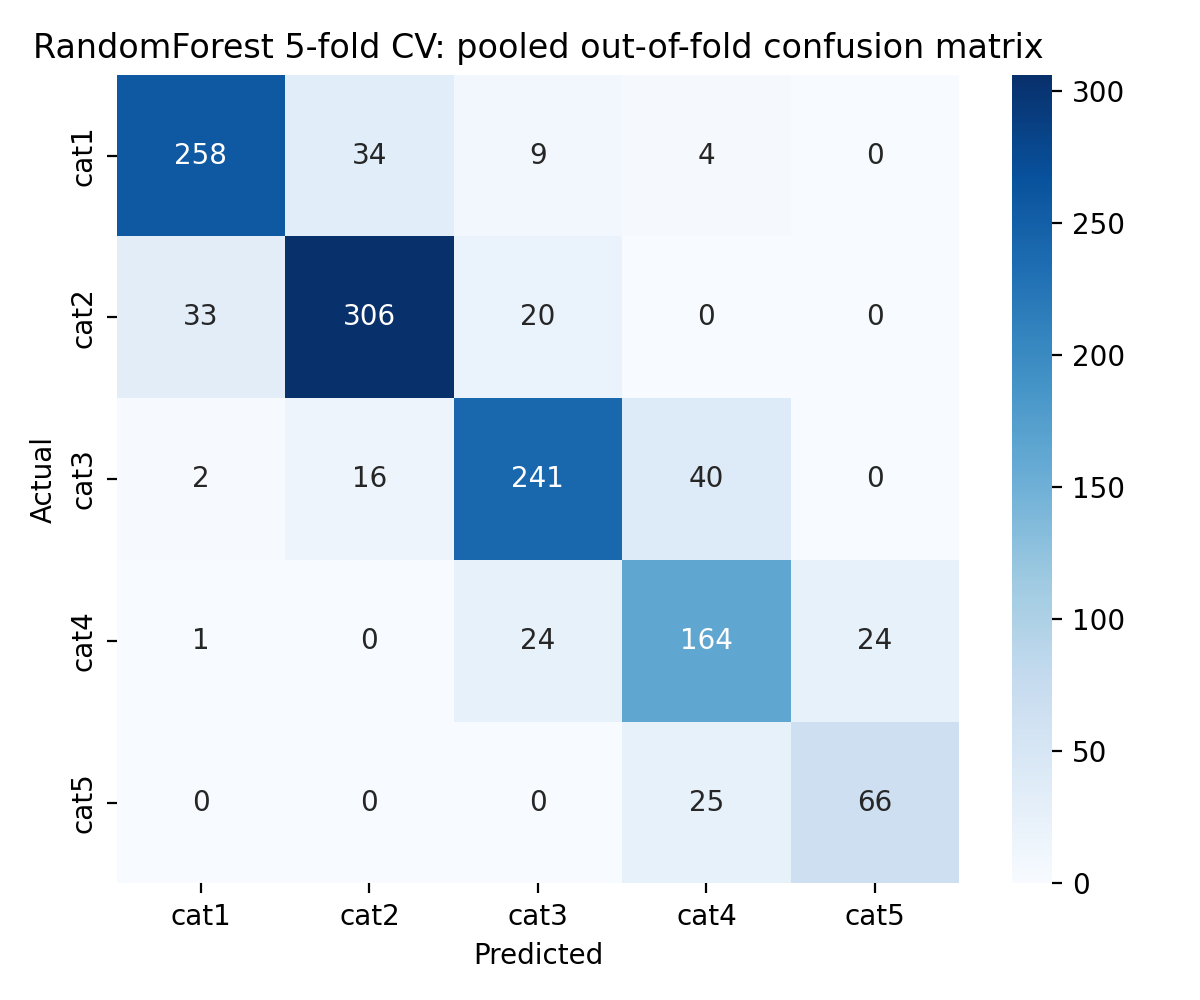

Saved confusion matrix figure to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/random_forest/rf_cv_confusion_matrix.png


In [8]:
cm = confusion_matrix(oof_predictions_df["true_label"], oof_predictions_df["pred_label"])
cm_df = pd.DataFrame(cm, index=CATEGORIES, columns=CATEGORIES)
cm_df.to_csv(confusion_table)

print(f"Saved pooled out-of-fold confusion matrix to {confusion_table}")
print(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RandomForest 5-fold CV: pooled out-of-fold confusion matrix")
plt.tight_layout()
plt.savefig(confusion_fig, dpi=200)
plt.show()

print(f"Saved confusion matrix figure to {confusion_fig}")

### Final model for interpretation (fit on all labeled data)

The CV loop above is what the reported macro-F1/balanced-accuracy numbers come from. For the feature-importance and SHAP panels, we additionally fit one model on *all* 1267 labeled figures (same grid search, same class weighting) purely for interpretation -- this final model is not used for any reported performance metric.

In [9]:
inf_cols = [c for c in FEATURES if np.isinf(df[c]).any()]
df_final = clip_infinite_values(df, df, inf_cols)
X_all, y_all = df_final[FEATURES], df_final["label"]

final_grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    PARAM_GRID, cv=5, scoring="f1_macro", n_jobs=-1,
)
final_grid_search.fit(X_all, y_all)
best_rf_final = final_grid_search.best_estimator_

print(f"Final model (fit on all {len(df_final)} figures) best params: {final_grid_search.best_params_}")

Final model (fit on all 1267 figures) best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}


### Feature importance (final model)

Saved feature importance to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/random_forest/rf_final_feature_importance.csv


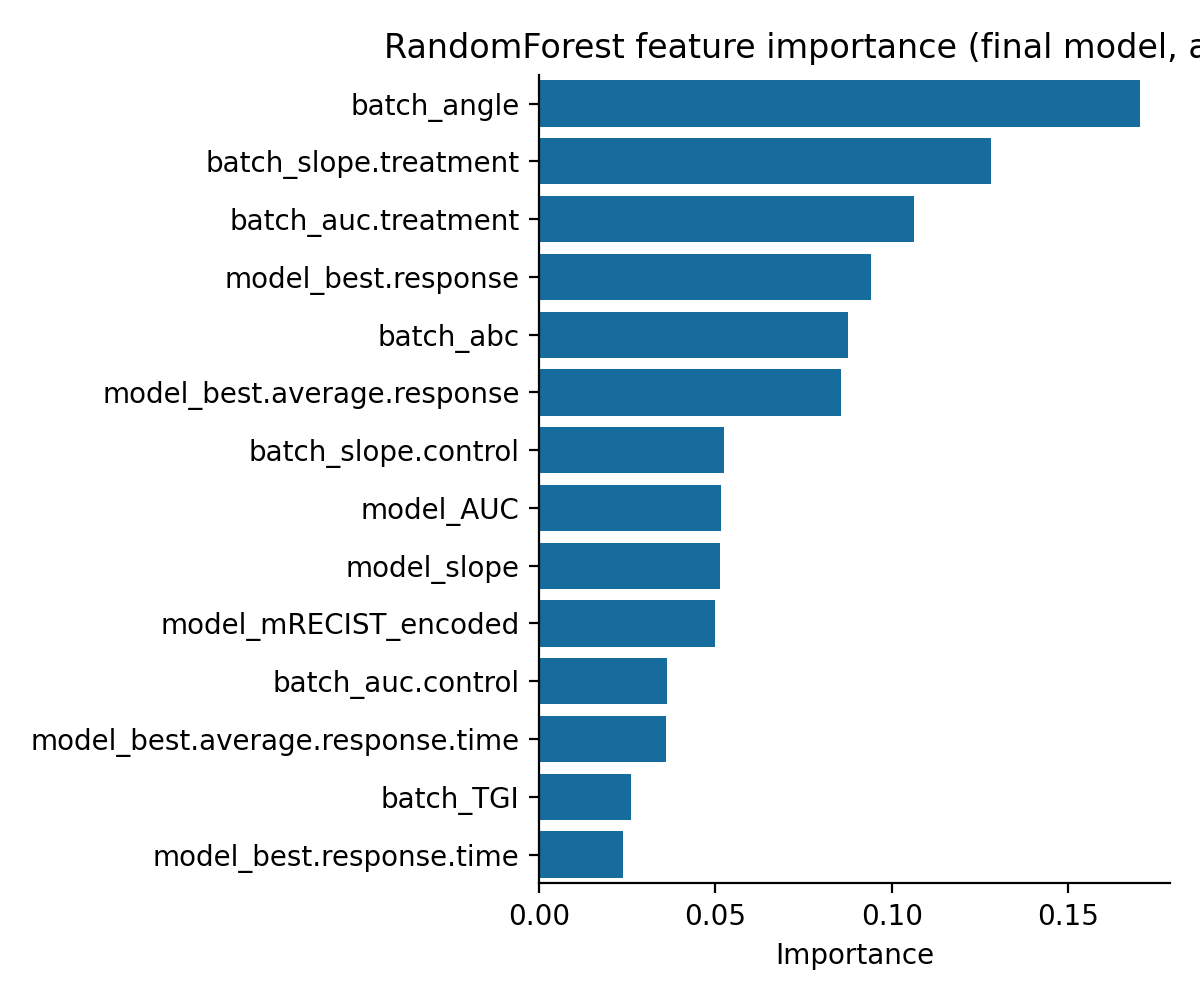

                             feature  importance
9                        batch_angle    0.170353
8              batch_slope.treatment    0.128197
11               batch_auc.treatment    0.106337
1                model_best.response    0.094154
12                         batch_abc    0.087675
3        model_best.average.response    0.085519
7                batch_slope.control    0.052556
5                          model_AUC    0.051744
6                        model_slope    0.051274
0              model_mRECIST_encoded    0.049900
10                 batch_auc.control    0.036312
4   model_best.average.response.time    0.036025
13                         batch_TGI    0.025993
2           model_best.response.time    0.023961

In [10]:
importances = pd.DataFrame({
    "feature": FEATURES,
    "importance": best_rf_final.feature_importances_,
}).sort_values("importance", ascending=False)
importances.to_csv(importance_table, index=False)

print(f"Saved feature importance to {importance_table}")

plt.figure(figsize=(6, 5))
sns.barplot(x="importance", y="feature", data=importances, color="#0072B2")
plt.xlabel("Importance")
plt.ylabel("")
plt.title("RandomForest feature importance (final model, all data)")
sns.despine()
plt.tight_layout()
plt.savefig(importance_fig, dpi=200)
plt.show()

importances

### SHAP summary (final model)

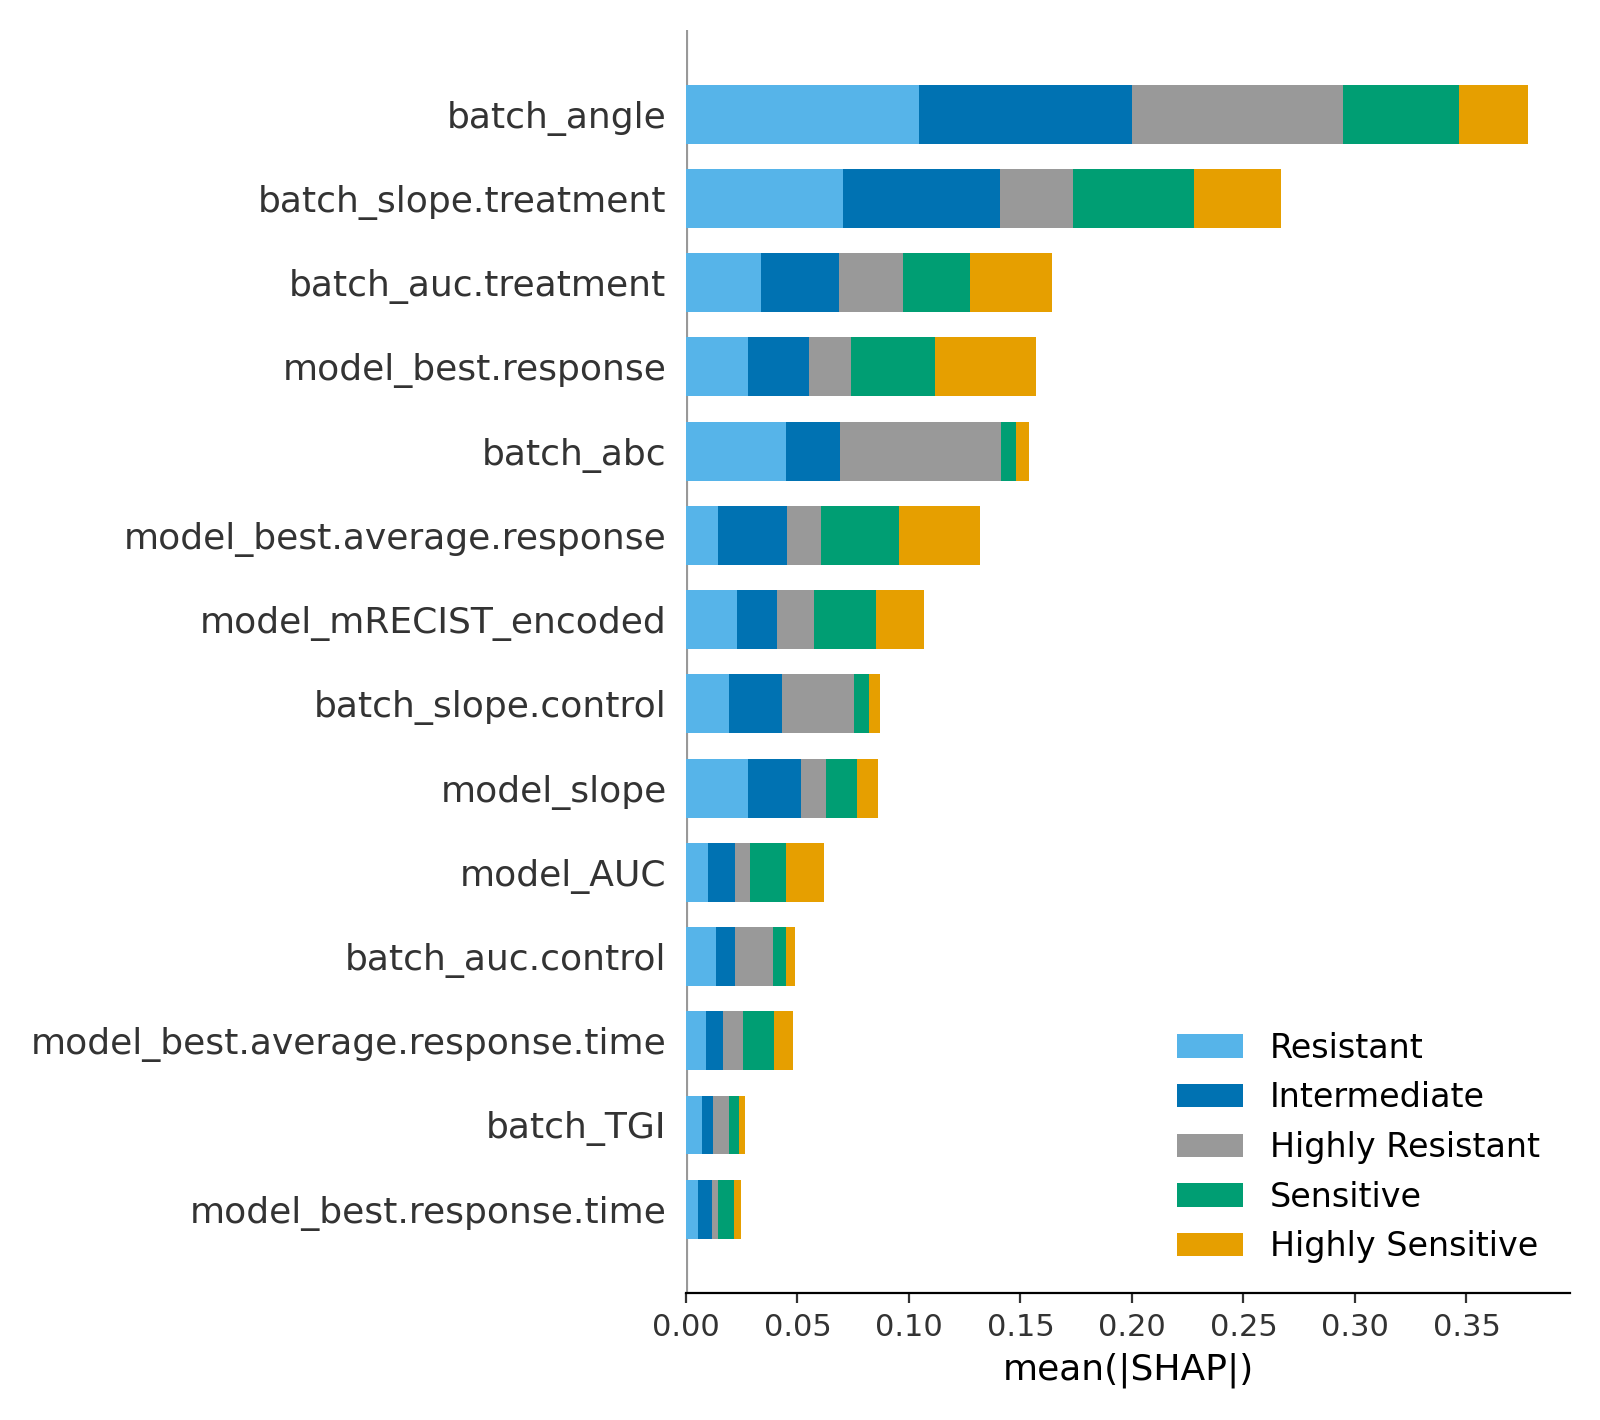

Saved SHAP summary to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/random_forest/rf_final_shap_summary.png


In [11]:
explainer = shap.TreeExplainer(best_rf_final)
shap_values = explainer.shap_values(X_all)

label_lookup = {0: "Highly Resistant", 1: "Resistant", 2: "Intermediate", 3: "Sensitive", 4: "Highly Sensitive"}
current_classes = list(best_rf_final.classes_)
desired_order = [0, 1, 2, 3, 4]
ordered_shap_values = [shap_values[:, :, current_classes.index(i)] for i in desired_order]
ordered_cat_names = [label_lookup[i] for i in desired_order]
nature_colors = ["#56B4E9", "#0072B2", "#999999", "#009E73", "#E69F00"]

plt.figure(figsize=(6, 6))
shap.summary_plot(
    ordered_shap_values, X_all, plot_type="bar", class_names=ordered_cat_names,
    color=ListedColormap(nature_colors), max_display=14, show=False,
)
ax = plt.gca()
ax.set_xlabel("mean(|SHAP|)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(shap_fig, dpi=200)
plt.show()

print(f"Saved SHAP summary to {shap_fig}")

In [12]:
shap_by_class = pd.DataFrame({
    label_lookup[cls]: np.abs(shap_values[:, :, current_classes.index(cls)]).mean(axis=0)
    for cls in range(5)
}, index=FEATURES)
shap_by_class = shap_by_class.loc[shap_by_class.sum(axis=1).sort_values(ascending=False).index]
shap_by_class.index.name = "feature"
shap_by_class.to_csv(shap_by_class_table)

print(f"Saved per-class SHAP magnitudes to {shap_by_class_table}")
shap_by_class

Saved per-class SHAP magnitudes to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/random_forest/rf_final_shap_by_class.csv


                                   Highly Resistant  Resistant  Intermediate  Sensitive  Highly Sensitive
feature                                                                                                    
batch_angle                                0.094763   0.104379      0.095666   0.051866          0.030879
batch_slope.treatment                      0.033054   0.070575      0.070136   0.054183          0.039112
batch_auc.treatment                        0.028641   0.033836      0.034725   0.030181          0.036713
model_best.response                        0.018925   0.027726      0.027458   0.037519          0.045225
batch_abc                                  0.071892   0.044698      0.024477   0.006915          0.005883
model_best.average.response                0.015365   0.014546      0.030648   0.034979          0.036126
model_mRECIST_encoded                      0.016391   0.023024      0.017933   0.027711          0.021822
batch_slope.control                        0

### Save final model and metadata

In [13]:
joblib.dump(best_rf_final, checkpoint_dir / "best_rf.joblib")

metadata = {
    "features": FEATURES,
    "mrecist_mapping": MRECIST_MAP,
    "label_mapping": {i: cat for i, cat in enumerate(CATEGORIES)},
    "cv_best_params_per_fold": [r["best_params"] for r in fold_results],
    "final_model_best_params": final_grid_search.best_params_,
}
with open(checkpoint_dir / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

joblib.dump(
    {
        "model": best_rf_final,
        "features": FEATURES,
        "mrecist_mapping": MRECIST_MAP,
        "label_mapping": {i: cat for i, cat in enumerate(CATEGORIES)},
    },
    checkpoint_dir / "rf_complete_package.joblib",
)

print(f"Saved final model and metadata to {checkpoint_dir}")

Saved final model and metadata to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/random_forest
